# PLSDA Feature Importance Analysis

Runs PLSDA feature importance analysis on saved object-level feature table to analyze feature importance.

In [1]:
%load_ext autoreload
%autoreload 2

## Run PLSDA for all classes

In [17]:
from object_xgb.pls_analysis import (
    calculate_total_vip,
    calculate_variance_explained,
    calculate_vip,
    load_pls_data,
    plot_plsda_biplots,
    run_plsda,
)

In [18]:
from os.path import expanduser

# The data contains 3 classes: hyphal nuclei, epithelial nuclei, invaded epithelial nuclei
X, y, feature_cols = load_pls_data(
    csv_path=expanduser(
        '~/A8/Data_Roan/260123_Cocu_Phalloidin/Cocu_Cet112_Ca922_Phalloidin_low_01_CY5, DAPI/Substack (30-40)/Substack (30-40)_full_features.csv'
    )
)
pls, mask, cats = run_plsda(X, y, n_components=3)
var_explained = calculate_variance_explained(pls, X)
vips = calculate_vip(pls, X.columns)
total_vip = calculate_total_vip(vips)

In [19]:
print(total_vip)

                    Component 1  Component 2  Component 3  Total VIP
frangi_mean            1.271420     0.163071     0.639455   1.432482
frangi_var             1.218467     0.015323     0.663515   1.387497
log_area               1.331035     0.142749     0.153863   1.347482
raw_mean               1.322640     0.085471     0.131902   1.331946
glcm_dissimilarity     1.310267     0.120435     0.042239   1.316468
...                         ...          ...          ...        ...
lbp_0                  0.002300     0.532903     0.289163   0.606305
lbp_6                  0.514809     0.286086     0.142312   0.605910
raw_hist_0             0.337641     0.050698     0.409174   0.532912
lbp_1                  0.041232     0.485630     0.195946   0.525292
raw_hist_1             0.159762     0.125469     0.043687   0.207786

[67 rows x 4 columns]


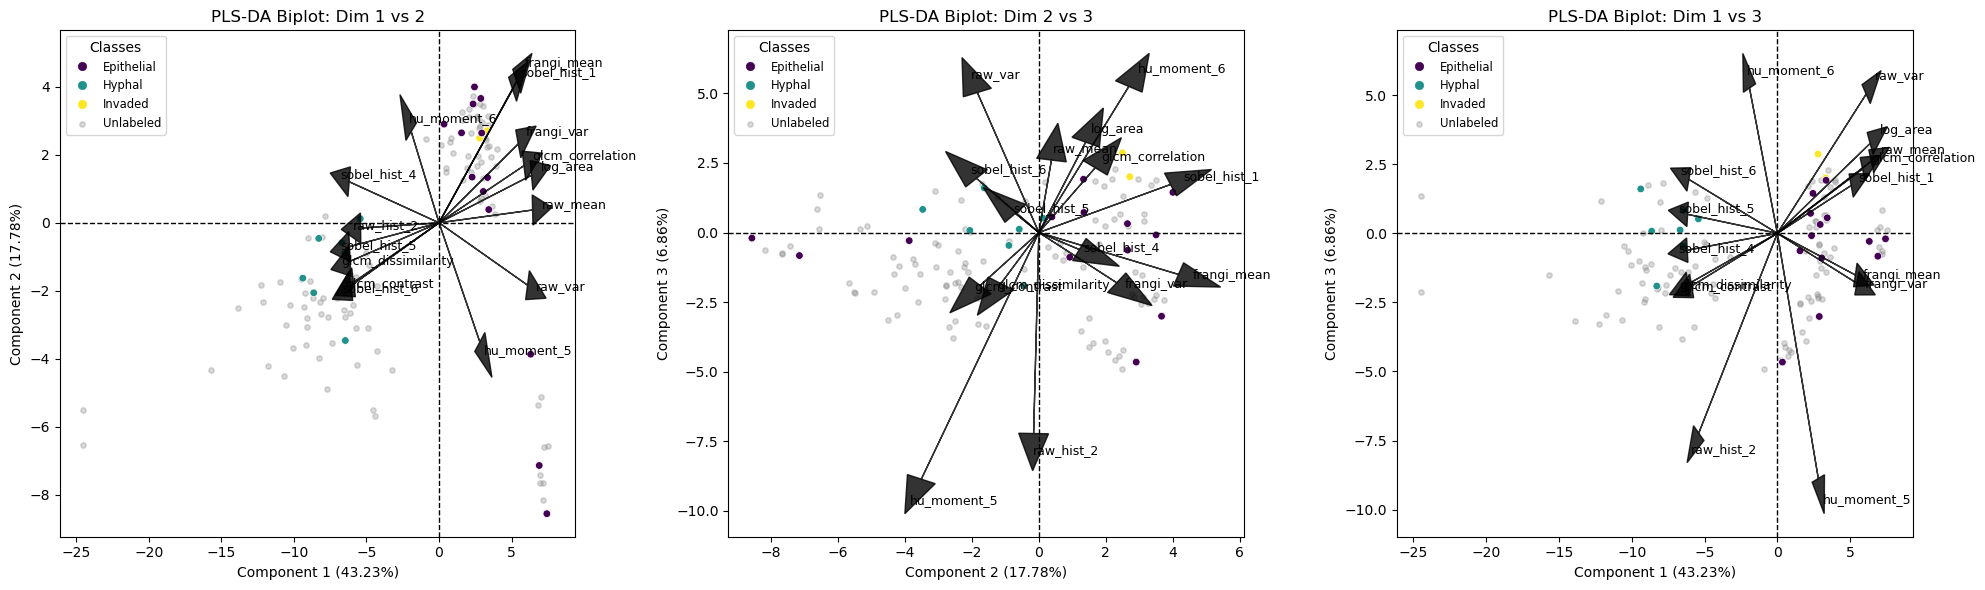

In [11]:
plot_plsda_biplots(pls, X, y, mask, feature_cols, var_explained, 15)

In [14]:
from object_xgb.pls_analysis import plot_plsda_3d

plot_plsda_3d(pls, X, y, mask, feature_cols, var_explained, top_n_features=15)

[Object XGB] 3D Biplot saved to output/plsda/plsda_3d.html


Based on the 3D plot, we saw that the invaded and non-invaded nuclei can be separated, although the separation is not very linear. However, they are both well separated from the hyphal nuclei. We now look at what best separates pairs of classes to identify the top features between pairs of classes. 

## Run Pairwise comparisons

In [22]:
from object_xgb.pls_analysis import (
    analyze_all_pairs,
    analyze_grouped_separation,
)

pair_table = analyze_all_pairs(X, y, feature_cols)
print(
    pair_table.sort_values('Epithelial vs Invaded', ascending=False).head(30)
)

               Epithelial vs Hyphal  Epithelial vs Invaded  Hyphal vs Invaded
hu_moment_5                0.628981               2.569061           0.331977
hu_moment_6                0.480061               2.474694           0.440821
raw_hist_6                 0.048839               2.132245           0.913377
hu_moment_4                0.734528               2.066660           0.206440
hu_moment_2                0.363217               2.047711           0.216659
frangi_var                 1.423121               1.719452           1.256024
raw_hist_7                 0.540963               1.653817           1.218728
frangi_hist_7              0.943948               1.482010           0.657323
frangi_mean                1.472023               1.481009           1.310236
hu_moment_3                0.140200               1.421232           0.258625
sobel_hist_1               1.324907               1.389829           1.204610
raw_hist_2                 1.173393               1.345296      

In [20]:
group_vips = analyze_grouped_separation(X, y, [1, 3], 2, feature_cols)
print(group_vips.sort_values(group_vips.columns[0], ascending=False).head(10))

                    Epithelial+Invaded vs Hyphal
log_area                                1.536511
raw_mean                                1.520649
glcm_dissimilarity                      1.499588
sobel_hist_6                            1.474224
glcm_contrast                           1.467944
sobel_hist_5                            1.450584
glcm_correlation                        1.440644
frangi_mean                             1.429113
sobel_hist_4                            1.386797
frangi_var                              1.356352


## Test XGBoost model training

Test feature selection using pair-wise PLSDA + XGBoost

In [1]:
from os.path import expanduser

import pandas as pd

from object_xgb.feature_selection import PairwisePLSFeatureSelector
from object_xgb.pls_analysis import load_pls_data
from object_xgb.xgboost_classifier import ObjectXGBoostClassifier

data_dir = expanduser(
    '~/A8/Data_Roan/260123_Cocu_Phalloidin/Cocu_Cet112_Ca922_Phalloidin_low_01_CY5, DAPI/Substack (30-40)/Substack (30-40)_full_features.csv'
)

# Assuming you loaded the original CSV into 'df'
X, y, _ = load_pls_data(data_dir)
original_df = pd.read_csv(data_dir)  # To keep slice_id and label

# 1. Feature Selection
selector = PairwisePLSFeatureSelector(threshold=1.2)
X_red = selector.fit_transform(X, y)

# 2. Train
clf = ObjectXGBoostClassifier()
clf.train(X_red, y)

# 3. Get full report
results = clf.predict_full_report(X_red, y, original_df)
print(results.head())

[Feature Selection] Selected 34/67 features with pairwise VIP > 1.2
[XGBoost] Calculating balanced sample weights...
[XGBoost] Training on 22 labeled samples...
[XGBoost] Training complete.
[XGBoost] Generating full report for 120 objects...
   slice_id  label  true_label  predicted_label
0         0      1           0                2
1         0      2           1                1
2         0      3           0                2
3         0      4           1                1
4         0      5           0                2


/opt/miniconda3/envs/microsam/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:48:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [4]:
results.to_csv('output/plsda/xgb_predictions.csv')